In [1]:
import os
import json

# Create the .kaggle folder if it doesn't exist
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

# Write your kaggle.json credentials
kaggle_credentials = {
    "username": "tsheringtobden",   # replace this
    "key": "export KAGGLE_API_TOKEN=KGAT_e9ad0c688d446c27bf1b8cdacf82cc03"            # replace with your token
}

# Save to the correct location
kaggle_json_path = os.path.expanduser("~/.kaggle/kaggle.json")
with open(kaggle_json_path, "w") as f:
    json.dump(kaggle_credentials, f)

# Set correct permissions (important on Linux/Mac, harmless on Windows)
os.chmod(kaggle_json_path, 0o600)

In [2]:
import kaggle

kaggle.api.authenticate()

kaggle.api.dataset_download_files(
    'tanyamishra260/health-risk-predictor-dataset',
    path='.',
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/tanyamishra260/health-risk-predictor-dataset


# Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# Load the dataset

In [6]:
df = pd.read_csv('final_data.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (97297, 33)

First 5 rows:


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,hypertension_risk_score,heart_disease_risk_score,obesity_risk_score,cholesterol_risk_score
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,7.9,0,0,0,30.5,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,51.716583,53.581369,50.796020,57.387241,51.492983
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,6.5,8.7,0,0,0,23.1,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,26.096162,47.946740,23.853485,36.219202,3.984993
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,8.1,1,0,0,22.2,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,54.830087,42.141104,38.977694,42.898797,21.793300
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,6.6,5.2,0,0,0,26.8,0.88,120,93,68,171,50,79,140,139,253,5.28,9.03,60.729521,60.286946,53.579555,52.194082,22.962029
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,7.4,5.0,0,0,0,21.2,0.78,92,67,67,210,52,125,160,137,184,12.74,7.20,32.778085,15.279074,18.721942,32.095465,34.296907


# Basic info

In [8]:
print("Column Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

Column Types
Age                                     int64
gender                                 object
ethnicity                              object
education_level                        object
income_level                           object
employment_status                      object
smoking_status                         object
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
family_history_diabetes                 int64
hypertension_history                    int64
cardiovascular_history                  int64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate                              int64
cholesterol_total                       int64
hdl_cholesterol      

# Create the three target columns

In [10]:
# Create binary targets from risk scores
# threshold of 50 means "at risk"

df['diabetes_target'] = (df['diabetes_risk_score'] >= 50).astype(int)
df['hypertension_target'] = (df['hypertension_risk_score'] >= 50).astype(int)
df['heart_disease_target'] = (df['heart_disease_risk_score'] >= 50).astype(int)

print("=== Target Distribution ===")
print("\nDiabetes (1=At Risk, 0=Not At Risk):")
print(df['diabetes_target'].value_counts())

print("\nHypertension (1=At Risk, 0=Not At Risk):")
print(df['hypertension_target'].value_counts())

print("\nHeart Disease (1=At Risk, 0=Not At Risk):")
print(df['heart_disease_target'].value_counts())

=== Target Distribution ===

Diabetes (1=At Risk, 0=Not At Risk):
diabetes_target
0    76836
1    20461
Name: count, dtype: int64

Hypertension (1=At Risk, 0=Not At Risk):
hypertension_target
0    73166
1    24131
Name: count, dtype: int64

Heart Disease (1=At Risk, 0=Not At Risk):
heart_disease_target
0    83799
1    13498
Name: count, dtype: int64


# Visualize target distributions

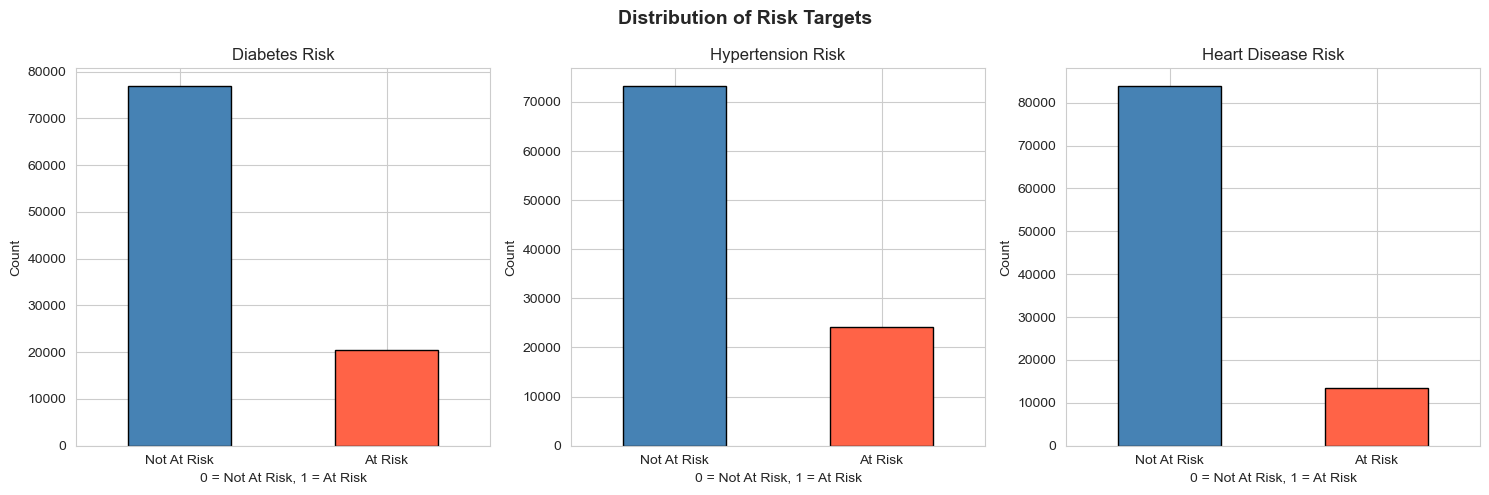

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

targets = ['diabetes_target', 'hypertension_target', 'heart_disease_target']
titles = ['Diabetes Risk', 'Hypertension Risk', 'Heart Disease Risk']
colors = [['steelblue', 'tomato'], ['steelblue', 'tomato'], ['steelblue', 'tomato']]

for i, (target, title) in enumerate(zip(targets, titles)):
    df[target].value_counts().plot(
        kind='bar', ax=axes[i],
        color=['steelblue', 'tomato'],
        edgecolor='black'
    )
    axes[i].set_title(title)
    axes[i].set_xlabel('0 = Not At Risk, 1 = At Risk')
    axes[i].set_ylabel('Count')
    axes[i].set_xticklabels(['Not At Risk', 'At Risk'], rotation=0)

plt.suptitle('Distribution of Risk Targets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualize key feature distributions for Diabetes


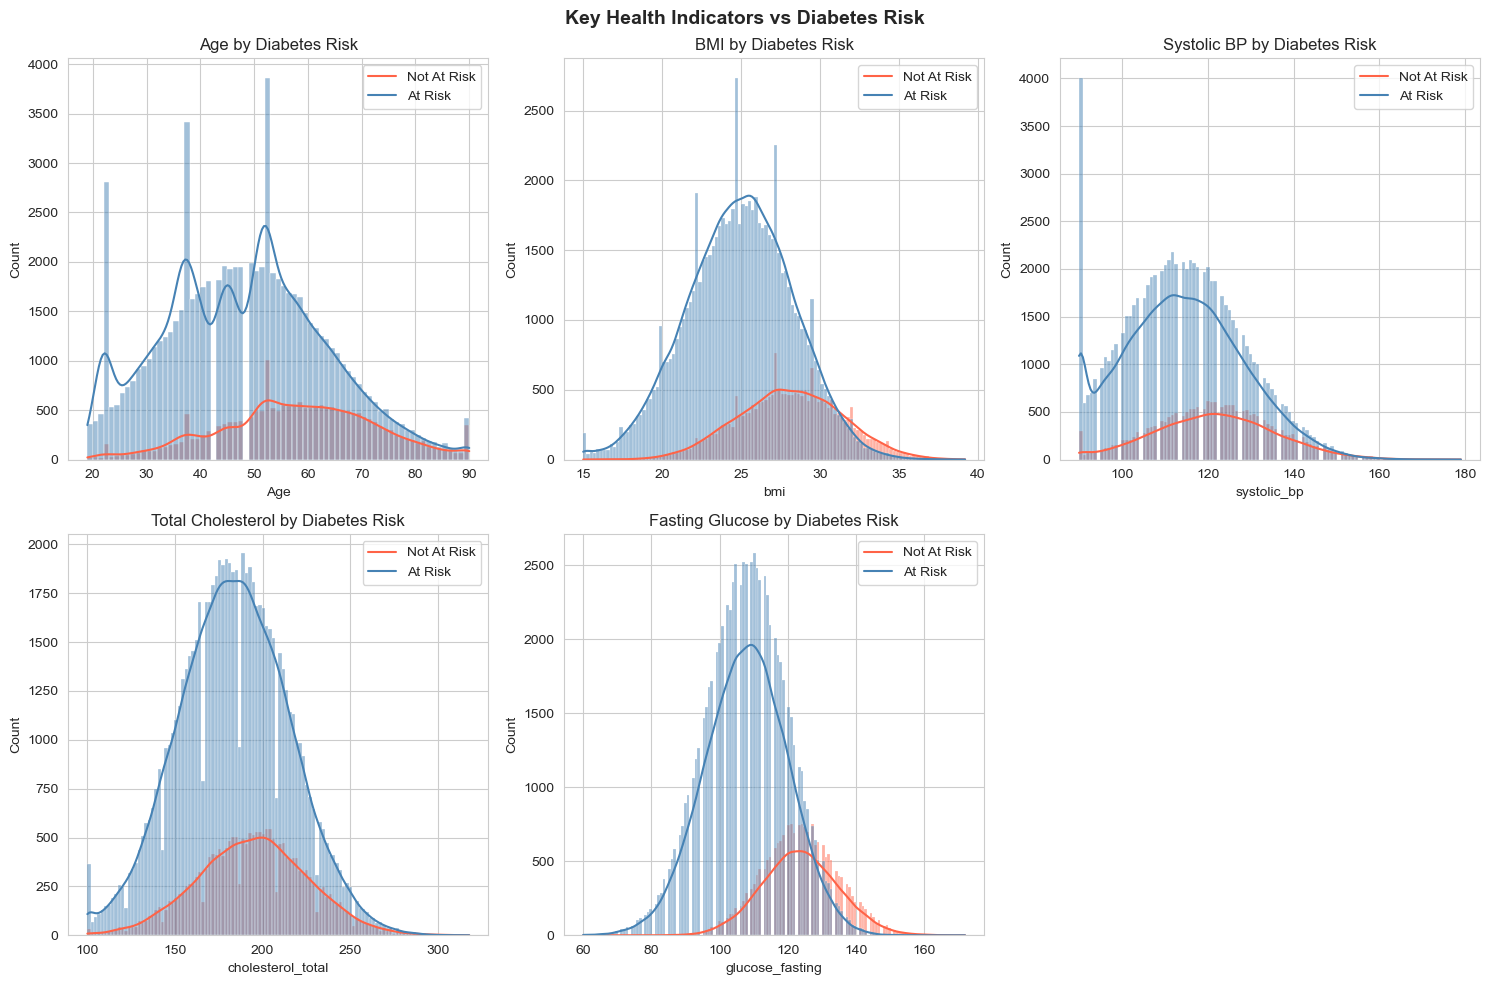

In [14]:
features = ['Age', 'bmi', 'systolic_bp', 'cholesterol_total', 'glucose_fasting']
feature_labels = ['Age', 'BMI', 'Systolic BP', 'Total Cholesterol', 'Fasting Glucose']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    sns.histplot(data=df, x=feature, hue='diabetes_target', 
                 kde=True, ax=axes[i],
                 palette={0: 'steelblue', 1: 'tomato'})
    axes[i].set_title(f'{label} by Diabetes Risk')
    axes[i].legend(['Not At Risk', 'At Risk'])

axes[5].axis('off')
plt.suptitle('Key Health Indicators vs Diabetes Risk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualize key feature distributions for Hypertension

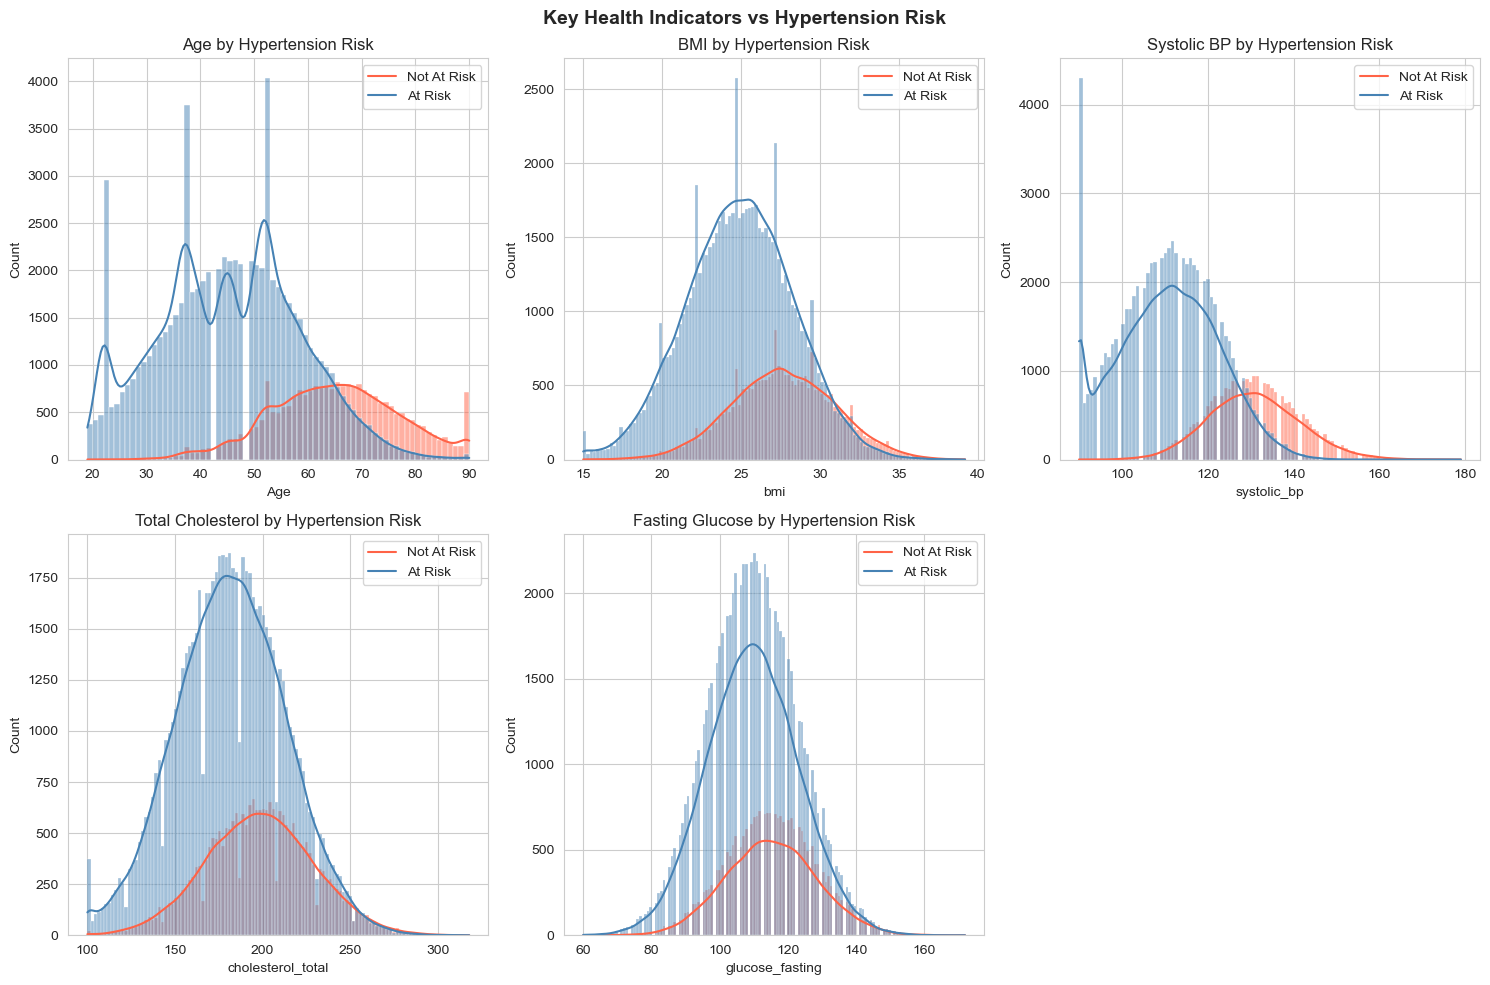

In [165]:
features = ['Age', 'bmi', 'systolic_bp', 'cholesterol_total', 'glucose_fasting']
feature_labels = ['Age', 'BMI', 'Systolic BP', 'Total Cholesterol', 'Fasting Glucose']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    sns.histplot(data=df, x=feature, hue='hypertension_target',
                 kde=True, ax=axes[i],
                 palette={0: 'steelblue', 1: 'tomato'})
    axes[i].set_title(f'{label} by Hypertension Risk')
    axes[i].legend(['Not At Risk', 'At Risk'])

axes[5].axis('off')
plt.suptitle('Key Health Indicators vs Hypertension Risk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualize key feature distributions for Heart Disease

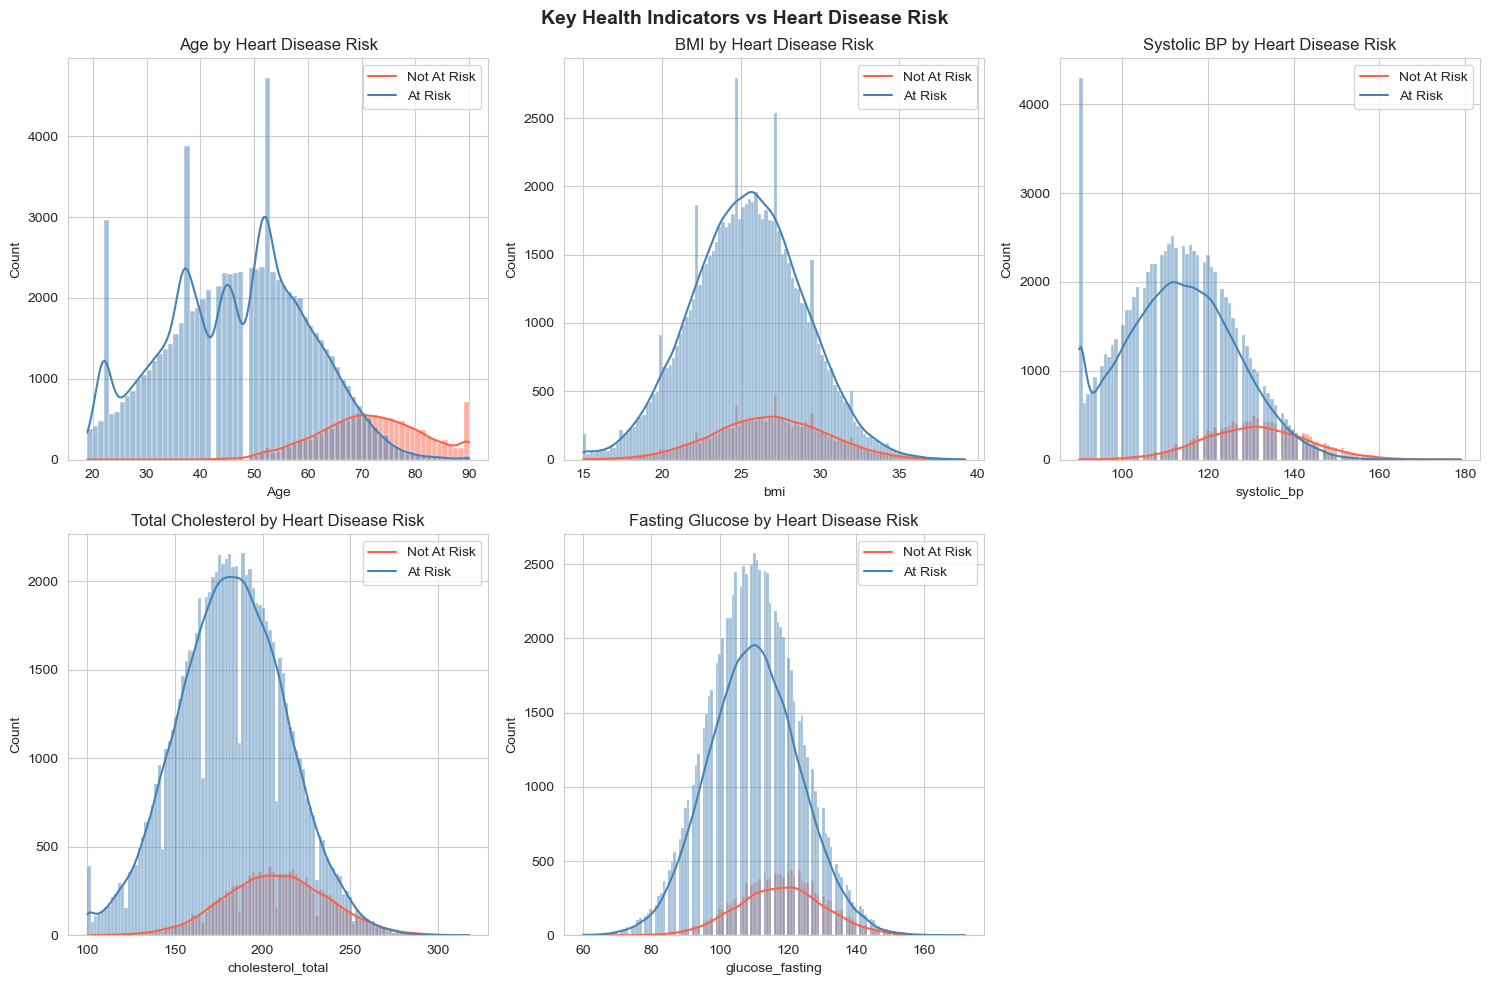

In [168]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    sns.histplot(data=df, x=feature, hue='heart_disease_target',
                 kde=True, ax=axes[i],
                 palette={0: 'steelblue', 1: 'tomato'})
    axes[i].set_title(f'{label} by Heart Disease Risk')
    axes[i].legend(['Not At Risk', 'At Risk'])

axes[5].axis('off')
plt.suptitle('Key Health Indicators vs Heart Disease Risk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation heatmap

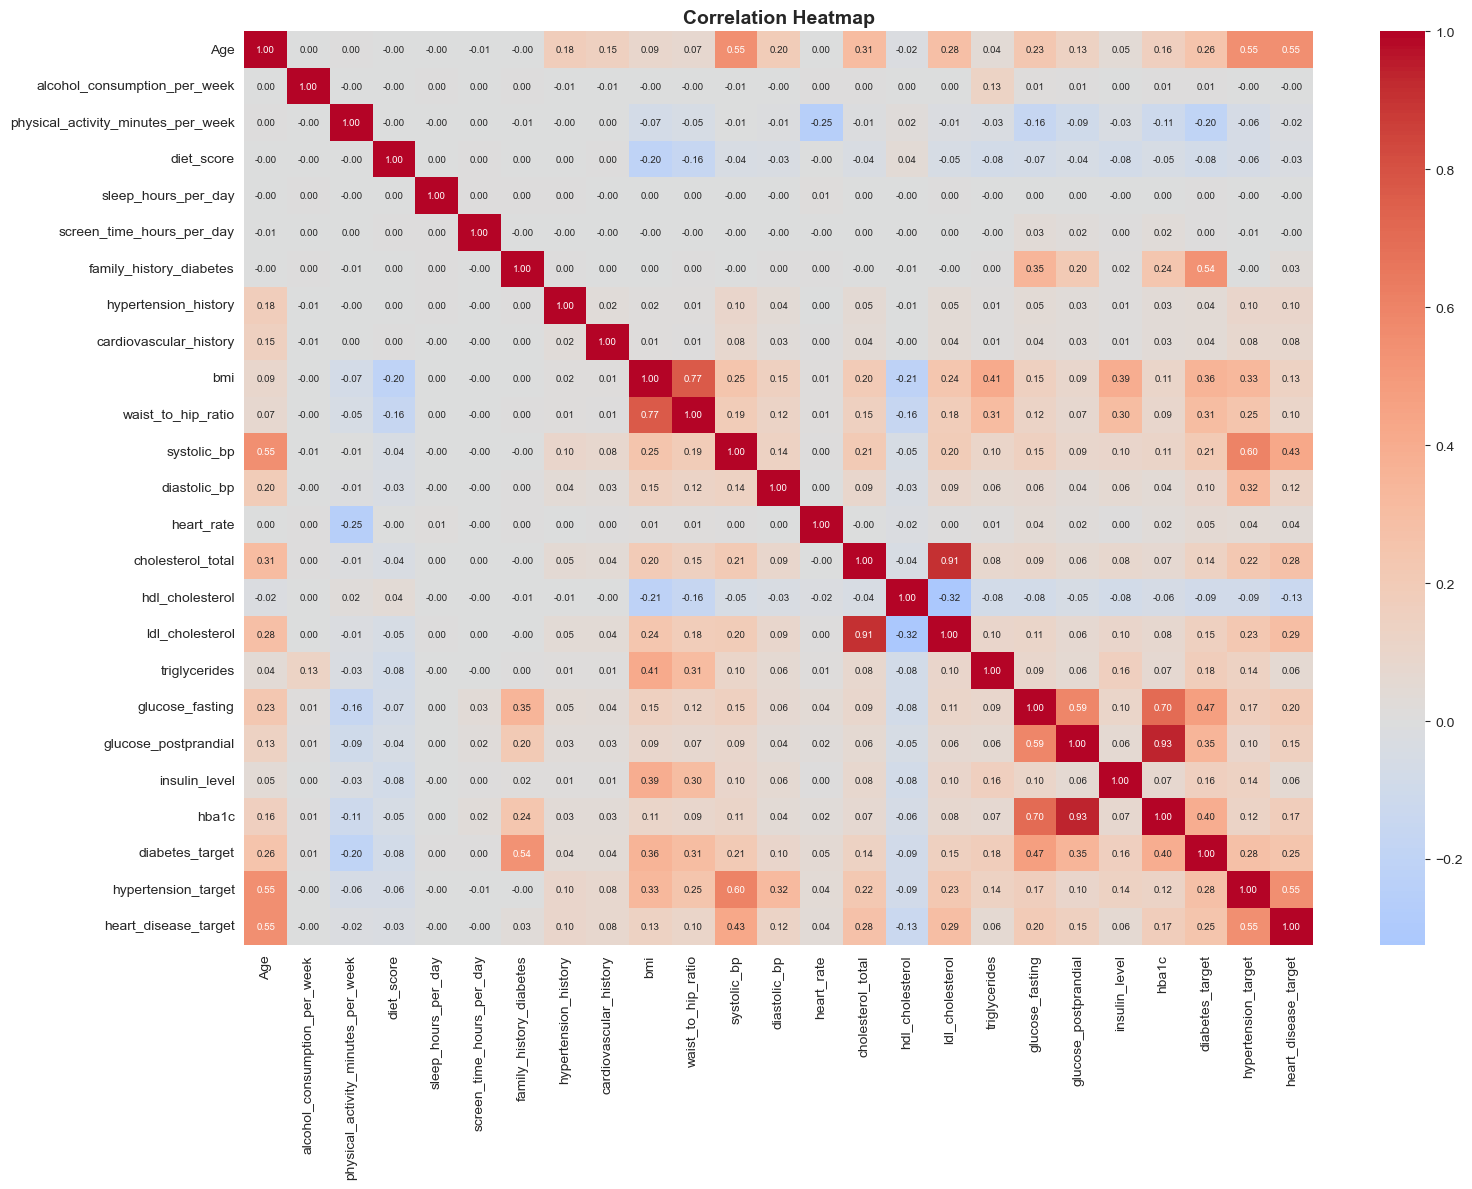

In [16]:
# Drop the original risk score columns and non-numeric for correlation
numeric_df = df.drop(columns=[
    'diabetes_risk_score', 'hypertension_risk_score',
    'heart_disease_risk_score', 'obesity_risk_score', 'cholesterol_risk_score',
    'gender', 'ethnicity', 'education_level', 'income_level',
    'employment_status', 'smoking_status'
])

plt.figure(figsize=(16, 12))
sns.heatmap(
    numeric_df.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    annot_kws={'size': 7}
)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 # Family history vs risk

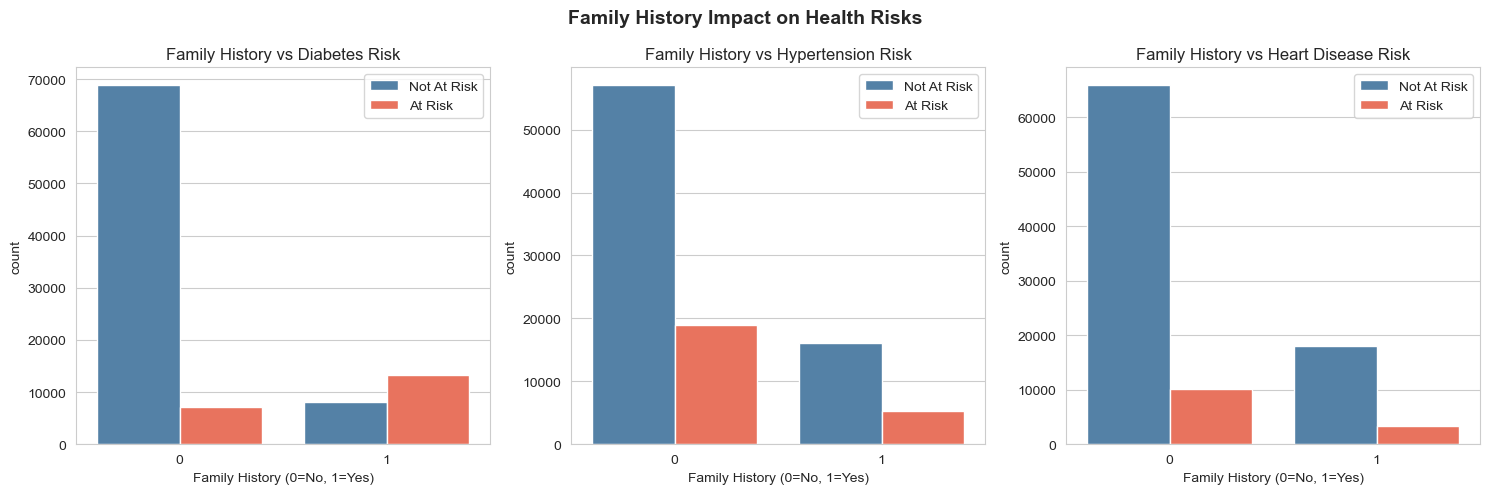

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

targets = ['diabetes_target', 'hypertension_target', 'heart_disease_target']
titles = ['Diabetes Risk', 'Hypertension Risk', 'Heart Disease Risk']

for i, (target, title) in enumerate(zip(targets, titles)):
    sns.countplot(
        data=df, x='family_history_diabetes',
        hue=target, ax=axes[i],
        palette={0: 'steelblue', 1: 'tomato'}
    )
    axes[i].set_title(f'Family History vs {title}')
    axes[i].set_xlabel('Family History (0=No, 1=Yes)')
    axes[i].legend(['Not At Risk', 'At Risk'])

plt.suptitle('Family History Impact on Health Risks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 # Define features and targets

In [20]:
# Drop the original risk score columns (they were only used to create targets)
# and drop the targets we won't use as features

FEATURES = [
    'Age', 'gender', 'ethnicity', 'education_level', 'income_level',
    'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
    'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day',
    'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history',
    'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
    'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
    'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial',
    'insulin_level', 'hba1c'
]

TARGETS = ['diabetes_target', 'hypertension_target', 'heart_disease_target']

X = df[FEATURES]
y_diabetes = df['diabetes_target']
y_hypertension = df['hypertension_target']
y_heart = df['heart_disease_target']

print("Features shape:", X.shape)
print("Diabetes target shape:", y_diabetes.shape)
print("Hypertension target shape:", y_hypertension.shape)
print("Heart disease target shape:", y_heart.shape)

Features shape: (97297, 28)
Diabetes target shape: (97297,)
Hypertension target shape: (97297,)
Heart disease target shape: (97297,)


# Separate categorical and numeric columns

In [22]:
categorical_cols = ['gender', 'ethnicity', 'education_level', 
                    'income_level', 'employment_status', 'smoking_status']

numeric_cols = [col for col in FEATURES if col not in categorical_cols]

print("Categorical columns:", categorical_cols)
print("\nNumeric columns:", numeric_cols)

Categorical columns: ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']

Numeric columns: ['Age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c']


# Build the preprocessing pipeline

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Preprocessing: scale numeric, encode categorical
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Split data for all three conditions

In [26]:
# Split for Diabetes
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X, y_diabetes, test_size=0.2, random_state=42, stratify=y_diabetes
)

# Split for Hypertension
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X, y_hypertension, test_size=0.2, random_state=42, stratify=y_hypertension
)

# Split for Heart Disease
X_train_hd, X_test_hd, y_train_hd, y_test_hd = train_test_split(
    X, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)

print("Train/Test Split Summary")
print(f"Diabetes     — Train: {X_train_d.shape[0]}, Test: {X_test_d.shape[0]}")
print(f"Hypertension — Train: {X_train_h.shape[0]}, Test: {X_test_h.shape[0]}")
print(f"Heart Disease— Train: {X_train_hd.shape[0]}, Test: {X_test_hd.shape[0]}")

Train/Test Split Summary
Diabetes     — Train: 77837, Test: 19460
Hypertension — Train: 77837, Test: 19460
Heart Disease— Train: 77837, Test: 19460


 # Handle class imbalance with class weights

In [28]:
from sklearn.utils.class_weight import compute_class_weight

def get_class_weights(y_train):
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', 
                                   classes=classes, y=y_train)
    return dict(zip(classes, weights))

cw_diabetes = get_class_weights(y_train_d)
cw_hypertension = get_class_weights(y_train_h)
cw_heart = get_class_weights(y_train_hd)

print("Class weights — Diabetes:", cw_diabetes)
print("Class weights — Hypertension:", cw_hypertension)
print("Class weights — Heart Disease:", cw_heart)

Class weights — Diabetes: {0: 0.6331505824168673, 1: 2.3775734620318896}
Class weights — Hypertension: {0: 0.6649097929337798, 1: 2.015980315980316}
Class weights — Heart Disease: {0: 0.5805352108474172, 1: 3.6042322652343026}


# Import model libraries

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Define all models

In [32]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', max_depth=10, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100, 
        max_depth=10, random_state=42, n_jobs=-1
    ),
    'SVM': LinearSVC(
        class_weight='balanced', max_iter=2000, random_state=42
    )
}

print("Models defined:")
for name in models:
    print(f"  - {name}")

Models defined:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - SVM


# Define training data for each condition

In [51]:
conditions = {
    'Diabetes': (X_train_d, X_test_d, y_train_d, y_test_d),
    'Hypertension': (X_train_h, X_test_h, y_train_h, y_test_h),
    'Heart Disease': (X_train_hd, X_test_hd, y_train_hd, y_test_hd)
}

# Train and evaluate all models

In [54]:
from sklearn.pipeline import Pipeline

results = {}  # stores all results

for condition, (X_tr, X_te, y_tr, y_te) in conditions.items():
    print(f"\n{'='*50}")
    print(f"Training models for: {condition}")
    print(f"{'='*50}")
    results[condition] = {}
    
    for model_name, model in models.items():
        print(f"  Training {model_name}...", end=' ')
        
        # Build full pipeline: preprocessor + model
        pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        
        # Train
        pipe.fit(X_tr, y_tr)
        
        # Predict
        y_pred = pipe.predict(X_te)
        
        # Evaluate
        acc  = accuracy_score(y_te, y_pred)
        prec = precision_score(y_te, y_pred, zero_division=0)
        rec  = recall_score(y_te, y_pred, zero_division=0)
        f1   = f1_score(y_te, y_pred, zero_division=0)
        cm   = confusion_matrix(y_te, y_pred)
        
        # Store results
        results[condition][model_name] = {
            'pipeline': pipe,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'confusion_matrix': cm,
            'y_pred': y_pred
        }
        
        print(f"Done! Accuracy: {acc:.4f} | F1: {f1:.4f}")


Training models for: Diabetes
Done! Accuracy: 0.9460 | F1: 0.8818
Done! Accuracy: 0.9230 | F1: 0.8340
Done! Accuracy: 0.9309 | F1: 0.8522
Done! Accuracy: 0.9450 | F1: 0.8799

Training models for: Hypertension
Done! Accuracy: 0.9446 | F1: 0.8952
Done! Accuracy: 0.9223 | F1: 0.8554
Done! Accuracy: 0.9233 | F1: 0.8586
Done! Accuracy: 0.9437 | F1: 0.8939

Training models for: Heart Disease
Done! Accuracy: 0.9355 | F1: 0.8036
Done! Accuracy: 0.9263 | F1: 0.7752
Done! Accuracy: 0.9302 | F1: 0.7884
Done! Accuracy: 0.9338 | F1: 0.7998


# Print comparison table

In [57]:
print("MODEL COMPARISON TABLE\n")

for condition in conditions:
    print(f"\n{condition}")
    print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("-" * 80)
    for model_name in models:
        r = results[condition][model_name]
        print(f"{model_name:<25} {r['accuracy']:>10.4f} {r['precision']:>10.4f} "
              f"{r['recall']:>10.4f} {r['f1']:>10.4f}")

MODEL COMPARISON TABLE


Diabetes
Model                       Accuracy  Precision     Recall         F1
--------------------------------------------------------------------------------
Logistic Regression           0.9460     0.8170     0.9577     0.8818
Decision Tree                 0.9230     0.7625     0.9203     0.8340
Random Forest                 0.9309     0.7743     0.9475     0.8522
SVM                           0.9450     0.8128     0.9592     0.8799

Hypertension
Model                       Accuracy  Precision     Recall         F1
--------------------------------------------------------------------------------
Logistic Regression           0.9446     0.8426     0.9548     0.8952
Decision Tree                 0.9223     0.7944     0.9264     0.8554
Random Forest                 0.9233     0.7907     0.9393     0.8586
SVM                           0.9437     0.8397     0.9554     0.8939

Heart Disease
Model                       Accuracy  Precision     Recall         F1
-----

# Diabetes Model Comparison

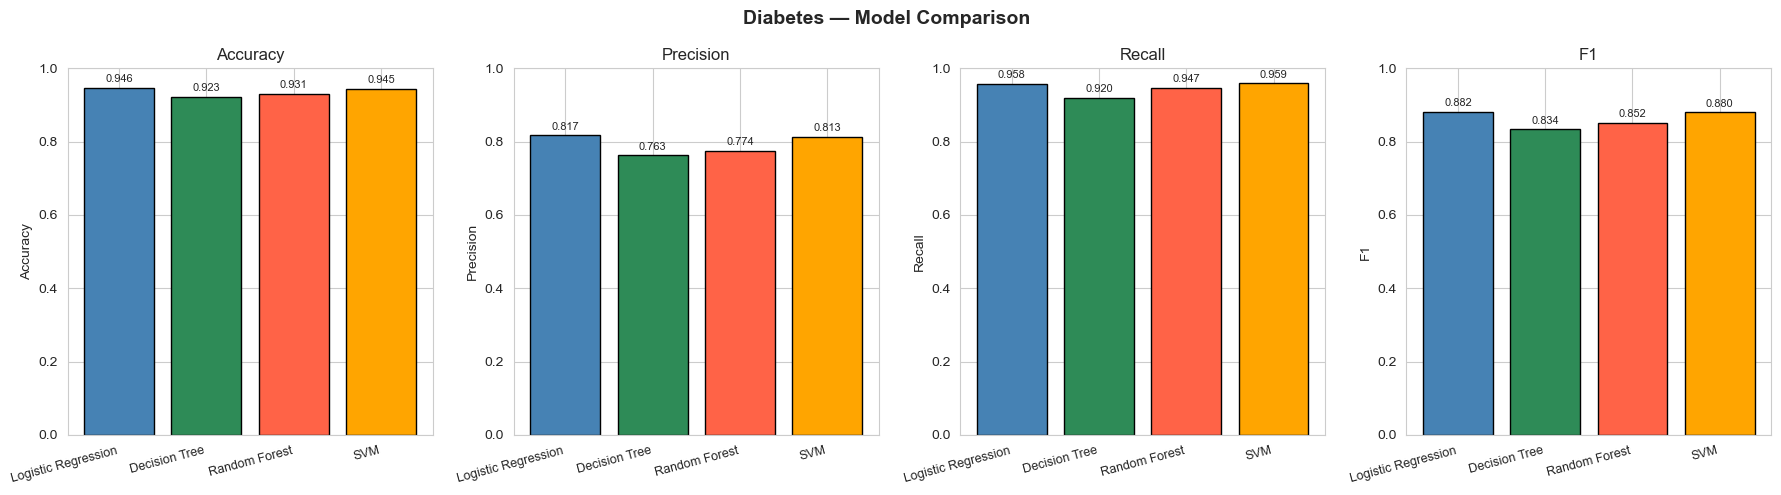

In [60]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ['accuracy', 'precision', 'recall', 'f1']
model_names = list(models.keys())
colors = ['steelblue', 'seagreen', 'tomato', 'orange']

for j, metric in enumerate(metrics):
    ax = axes[j]
    values = [results['Diabetes'][m][metric] for m in model_names]
    bars = ax.bar(model_names, values, color=colors, edgecolor='black')
    ax.set_title(f'{metric.capitalize()}')
    ax.set_ylim(0, 1)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel(metric.capitalize())
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Diabetes — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Hypertension Model Comparison

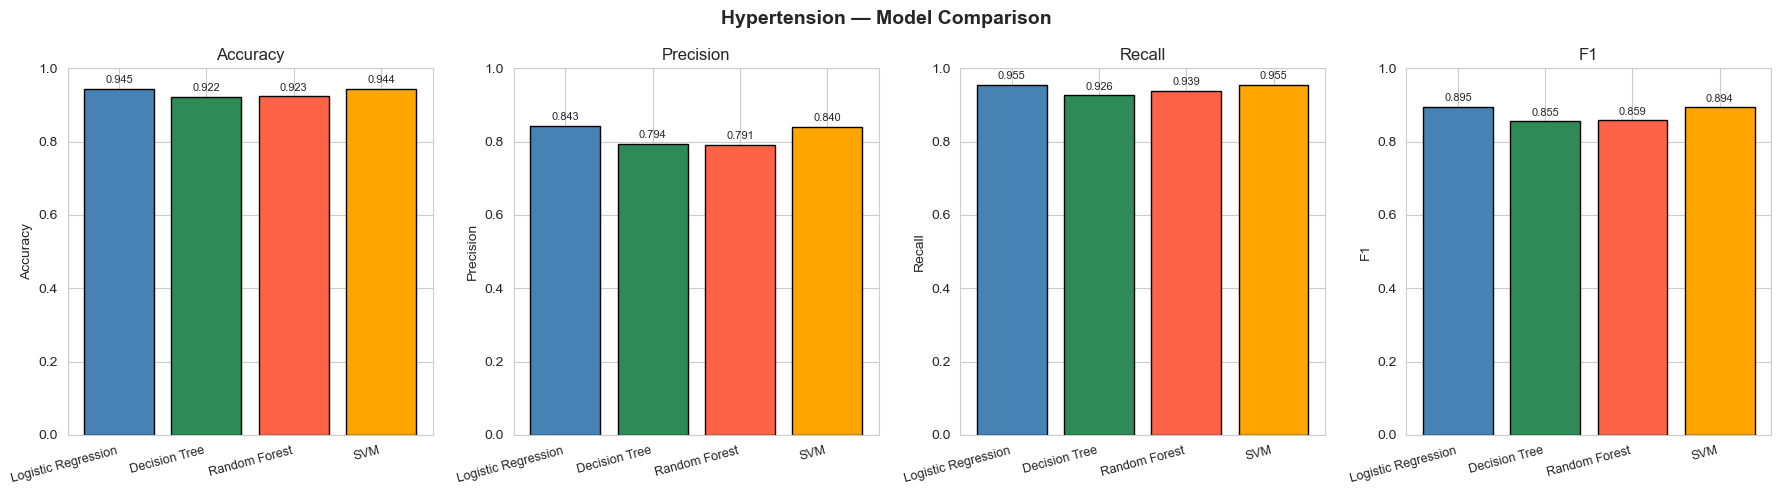

In [63]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for j, metric in enumerate(metrics):
    ax = axes[j]
    values = [results['Hypertension'][m][metric] for m in model_names]
    bars = ax.bar(model_names, values, color=colors, edgecolor='black')
    ax.set_title(f'{metric.capitalize()}')
    ax.set_ylim(0, 1)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel(metric.capitalize())
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Hypertension — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Heart Disease Model Comparison

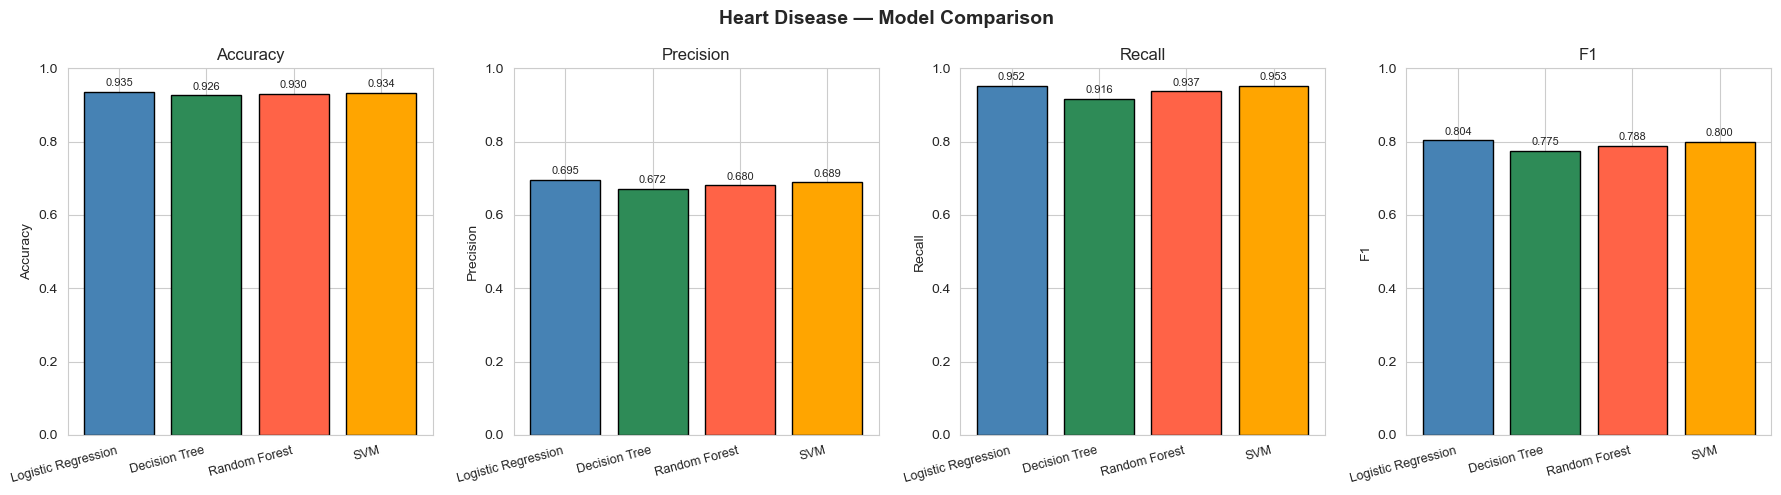

In [66]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for j, metric in enumerate(metrics):
    ax = axes[j]
    values = [results['Heart Disease'][m][metric] for m in model_names]
    bars = ax.bar(model_names, values, color=colors, edgecolor='black')
    ax.set_title(f'{metric.capitalize()}')
    ax.set_ylim(0, 1)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel(metric.capitalize())
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Heart Disease — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Confusion matrices for best model

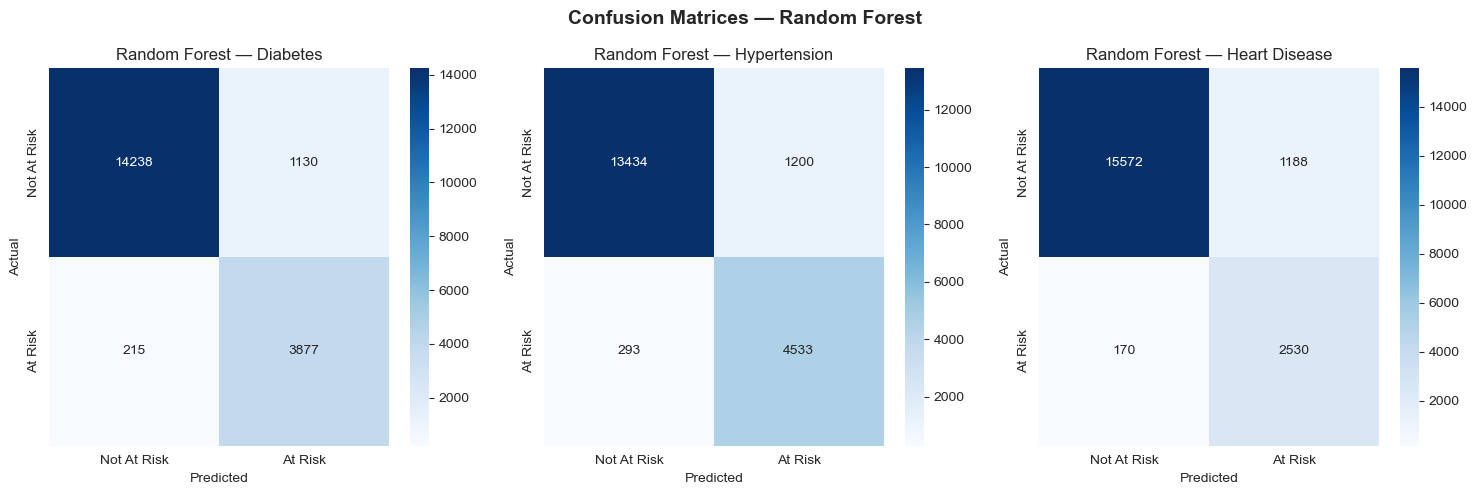

In [71]:
condition_names = list(conditions.keys())

# Plot confusion matrices for Random Forest (expected best performer)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, condition in enumerate(condition_names):
    cm = results[condition]['Random Forest']['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not At Risk', 'At Risk'],
                yticklabels=['Not At Risk', 'At Risk'])
    axes[i].set_title(f'Random Forest — {condition}')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Cross Validation

In [74]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# We'll cross-validate Logistic Regression since it's our best model
# Using 5-fold stratified cross validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_conditions = {
    'Diabetes': (X, y_diabetes),
    'Hypertension': (X, y_hypertension),
    'Heart Disease': (X, y_heart)
}

print("5-Fold Cross Validation — Logistic Regression\n")

cv_results = {}

for condition, (X_data, y_data) in cv_conditions.items():
    # Build pipeline with Logistic Regression
    pipe_cv = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=42
        ))
    ])
    
    # Cross validate on accuracy and f1
    acc_scores = cross_val_score(pipe_cv, X_data, y_data, 
                                  cv=cv, scoring='accuracy', n_jobs=-1)
    f1_scores  = cross_val_score(pipe_cv, X_data, y_data, 
                                  cv=cv, scoring='f1', n_jobs=-1)
    
    cv_results[condition] = {
        'acc_scores': acc_scores,
        'f1_scores': f1_scores
    }
    
    print(f" {condition} ")
    print(f"  Accuracy per fold : {[f'{s:.4f}' for s in acc_scores]}")
    print(f"  Accuracy Mean±Std : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"  F1 per fold       : {[f'{s:.4f}' for s in f1_scores]}")
    print(f"  F1 Mean±Std       : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print()

5-Fold Cross Validation — Logistic Regression

 Diabetes 
  Accuracy per fold : ['0.9473', '0.9467', '0.9462', '0.9484', '0.9463']
  Accuracy Mean±Std : 0.9470 ± 0.0008
  F1 per fold       : ['0.8847', '0.8831', '0.8823', '0.8868', '0.8825']
  F1 Mean±Std       : 0.8839 ± 0.0017

 Hypertension 
  Accuracy per fold : ['0.9428', '0.9446', '0.9405', '0.9427', '0.9439']
  Accuracy Mean±Std : 0.9429 ± 0.0014
  F1 per fold       : ['0.8918', '0.8954', '0.8886', '0.8918', '0.8941']
  F1 Mean±Std       : 0.8923 ± 0.0023

 Heart Disease 
  Accuracy per fold : ['0.9359', '0.9319', '0.9291', '0.9330', '0.9340']
  Accuracy Mean±Std : 0.9328 ± 0.0023
  F1 per fold       : ['0.8054', '0.7944', '0.7871', '0.7988', '0.8010']
  F1 Mean±Std       : 0.7973 ± 0.0062



# Visualize Cross Validation results

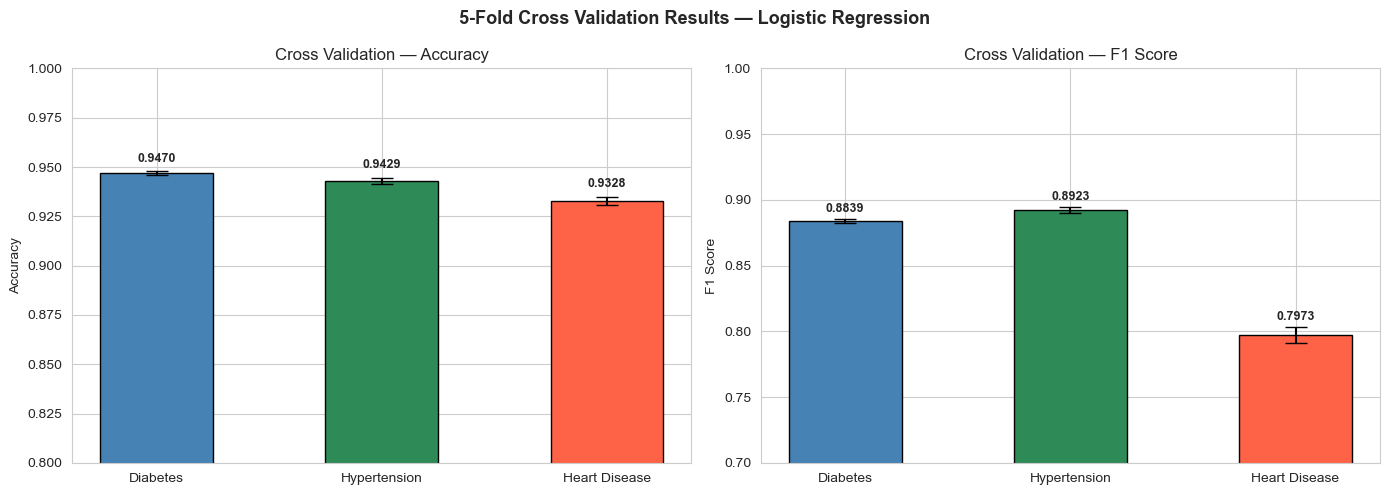

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
condition_names = list(cv_conditions.keys())
x = np.arange(len(condition_names))
width = 0.25

# Accuracy plot
acc_means = [cv_results[c]['acc_scores'].mean() for c in condition_names]
acc_stds  = [cv_results[c]['acc_scores'].std()  for c in condition_names]
axes[0].bar(x, acc_means, width=0.5, yerr=acc_stds, 
            color=['steelblue', 'seagreen', 'tomato'],
            capsize=8, edgecolor='black')
axes[0].set_title('Cross Validation — Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(condition_names)
axes[0].set_ylim(0.8, 1.0)
axes[0].set_ylabel('Accuracy')
for i, (mean, std) in enumerate(zip(acc_means, acc_stds)):
    axes[0].text(i, mean + std + 0.005, f'{mean:.4f}', 
                 ha='center', fontsize=9, fontweight='bold')

# F1 plot
f1_means = [cv_results[c]['f1_scores'].mean() for c in condition_names]
f1_stds  = [cv_results[c]['f1_scores'].std()  for c in condition_names]
axes[1].bar(x, f1_means, width=0.5, yerr=f1_stds,
            color=['steelblue', 'seagreen', 'tomato'],
            capsize=8, edgecolor='black')
axes[1].set_title('Cross Validation — F1 Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(condition_names)
axes[1].set_ylim(0.7, 1.0)
axes[1].set_ylabel('F1 Score')
for i, (mean, std) in enumerate(zip(f1_means, f1_stds)):
    axes[1].text(i, mean + std + 0.005, f'{mean:.4f}', 
                 ha='center', fontsize=9, fontweight='bold')

plt.suptitle('5-Fold Cross Validation Results — Logistic Regression', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Grid Search

In [82]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Logistic Regression
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs', 'saga'],
    'classifier__max_iter': [1000]
}

print("Grid Search — Logistic Regression")

best_models = {}

for condition, (X_tr, X_te, y_tr, y_te) in conditions.items():
    print(f"Tuning for {condition}...")
    
    # Build base pipeline
    pipe_gs = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            class_weight='balanced', random_state=42
        ))
    ])
    
    # Grid search with 5-fold CV
    grid_search = GridSearchCV(
        pipe_gs, param_grid,
        cv=5, scoring='f1',
        n_jobs=-1, verbose=0
    )
    
    grid_search.fit(X_tr, y_tr)
    
    # Evaluate best model on test set
    best_pipe = grid_search.best_estimator_
    y_pred = best_pipe.predict(X_te)
    
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    
    best_models[condition] = {
        'pipeline': best_pipe,
        'best_params': grid_search.best_params_,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    }
    
    print(f"  Best params : {grid_search.best_params_}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Precision   : {prec:.4f}")
    print(f"  Recall      : {rec:.4f}")
    print(f"  F1 Score    : {f1:.4f}")
    print()


Grid Search — Logistic Regression
Tuning for Diabetes...
  Best params : {'classifier__C': 10, 'classifier__max_iter': 1000, 'classifier__solver': 'saga'}
  Accuracy    : 0.9460
  Precision   : 0.8171
  Recall      : 0.9577
  F1 Score    : 0.8819

Tuning for Hypertension...
  Best params : {'classifier__C': 10, 'classifier__max_iter': 1000, 'classifier__solver': 'lbfgs'}
  Accuracy    : 0.9446
  Precision   : 0.8428
  Recall      : 0.9546
  F1 Score    : 0.8953

Tuning for Heart Disease...
  Best params : {'classifier__C': 10, 'classifier__max_iter': 1000, 'classifier__solver': 'lbfgs'}
  Accuracy    : 0.9355
  Precision   : 0.6955
  Recall      : 0.9519
  F1 Score    : 0.8038



# Compare before vs after tuning

In [89]:
print("Before vs After Grid Search Tuning\n")

for condition in conditions:
    before_acc = results[condition]['Logistic Regression']['accuracy']
    before_f1  = results[condition]['Logistic Regression']['f1']
    after_acc  = best_models[condition]['accuracy']
    after_f1   = best_models[condition]['f1']
    
    acc_diff = (after_acc - before_acc) * 100
    f1_diff  = (after_f1  - before_f1)  * 100
    
    print(f"{condition}")
    print(f"  Accuracy : {before_acc:.4f} → {after_acc:.4f}  "
          f"({'↑' if acc_diff > 0 else '↓'}{abs(acc_diff):.2f}%)")
    print(f"  F1 Score : {before_f1:.4f} → {after_f1:.4f}  "
          f"({'↑' if f1_diff > 0 else '↓'}{abs(f1_diff):.2f}%)")
    print()

Before vs After Grid Search Tuning

Diabetes
  Accuracy : 0.9460 → 0.9460  (↑0.01%)
  F1 Score : 0.8818 → 0.8819  (↑0.01%)

Hypertension
  Accuracy : 0.9446 → 0.9446  (↑0.01%)
  F1 Score : 0.8952 → 0.8953  (↑0.01%)

Heart Disease
  Accuracy : 0.9355 → 0.9355  (↑0.01%)
  F1 Score : 0.8036 → 0.8038  (↑0.01%)



# Visualize before vs after tuning

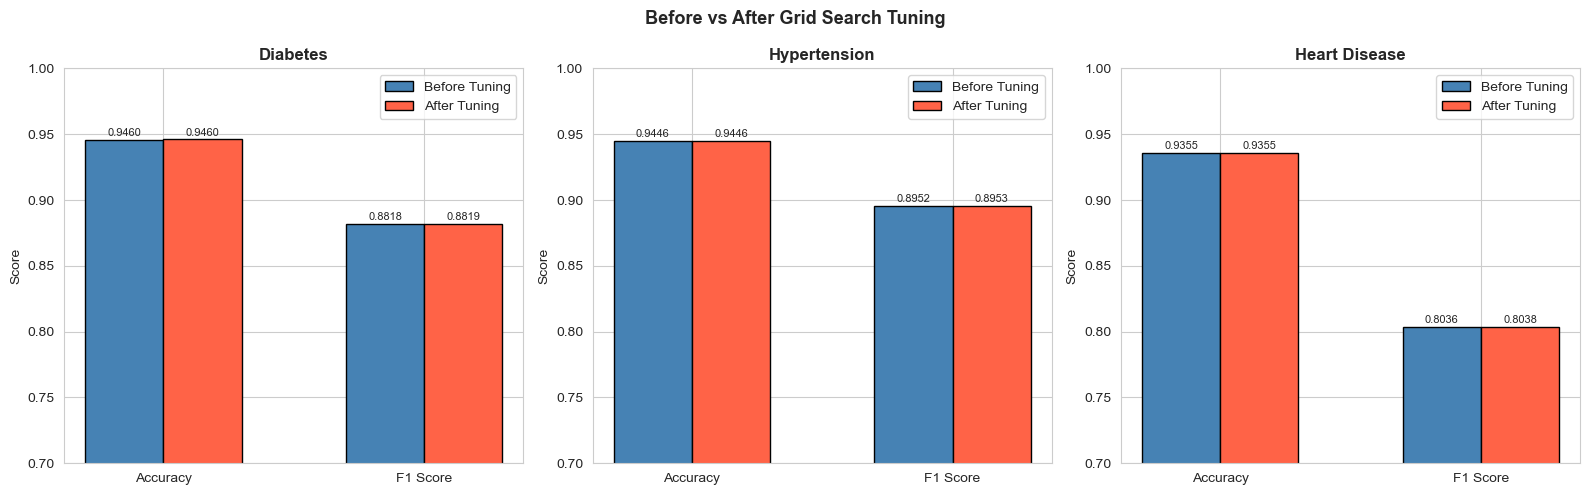

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
condition_names = list(conditions.keys())
x = np.arange(2)
width = 0.3

for i, condition in enumerate(condition_names):
    before_acc = results[condition]['Logistic Regression']['accuracy']
    before_f1  = results[condition]['Logistic Regression']['f1']
    after_acc  = best_models[condition]['accuracy']
    after_f1   = best_models[condition]['f1']

    bars1 = axes[i].bar(x - width/2, [before_acc, before_f1], 
                         width, label='Before Tuning', 
                         color='steelblue', edgecolor='black')
    bars2 = axes[i].bar(x + width/2, [after_acc, after_f1],   
                         width, label='After Tuning',  
                         color='tomato',    edgecolor='black')
    
    axes[i].set_title(condition, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(['Accuracy', 'F1 Score'])
    axes[i].set_ylim(0.7, 1.0)
    axes[i].legend()
    axes[i].set_ylabel('Score')

    for bar in bars1:
        axes[i].text(bar.get_x() + bar.get_width()/2, 
                     bar.get_height() + 0.003,
                     f'{bar.get_height():.4f}', 
                     ha='center', fontsize=8)
    for bar in bars2:
        axes[i].text(bar.get_x() + bar.get_width()/2, 
                     bar.get_height() + 0.003,
                     f'{bar.get_height():.4f}', 
                     ha='center', fontsize=8)

plt.suptitle('Before vs After Grid Search Tuning', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Build Voting Ensemble

In [97]:
from sklearn.ensemble import VotingClassifier

print("=== Voting Ensemble Classifier ===\n")

voting_results = {}

for condition, (X_tr, X_te, y_tr, y_te) in conditions.items():
    print(f"Training Voting Ensemble for {condition}...")

    # Define estimators (without pipeline — we'll wrap together)
    estimators = [
        ('lr', LogisticRegression(
            class_weight='balanced', C=10,
            max_iter=1000, random_state=42
        )),
        ('dt', DecisionTreeClassifier(
            class_weight='balanced', max_depth=10, random_state=42
        )),
        ('rf', RandomForestClassifier(
            class_weight='balanced', n_estimators=100,
            max_depth=10, random_state=42, n_jobs=-1
        )),
        ('svm', LinearSVC(
            class_weight='balanced', max_iter=2000, random_state=42
        ))
    ]

    # Voting classifier — hard voting = majority vote
    voting_clf = VotingClassifier(estimators=estimators, voting='hard')

    # Wrap in pipeline with preprocessor
    pipe_voting = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', voting_clf)
    ])

    # Train
    pipe_voting.fit(X_tr, y_tr)

    # Predict
    y_pred = pipe_voting.predict(X_te)

    # Evaluate
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    cm   = confusion_matrix(y_te, y_pred)

    voting_results[condition] = {
        'pipeline': pipe_voting,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'confusion_matrix': cm
    }

    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print()

=== Voting Ensemble Classifier ===

Training Voting Ensemble for Diabetes...
  Accuracy  : 0.9488
  Precision : 0.8323
  Recall    : 0.9472
  F1 Score  : 0.8860

Training Voting Ensemble for Hypertension...
  Accuracy  : 0.9453
  Precision : 0.8531
  Recall    : 0.9414
  F1 Score  : 0.8951

Training Voting Ensemble for Heart Disease...
  Accuracy  : 0.9408
  Precision : 0.7194
  Recall    : 0.9400
  F1 Score  : 0.8150



# Compare Voting Ensemble vs all individual models

In [108]:
print("Final Model Comparison\n")

for condition in conditions:
    print(f"--- {condition} ---")
    print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("-" * 65)
    
    # Individual models
    for model_name in models:
        r = results[condition][model_name]
        print(f"{model_name:<25} {r['accuracy']:>10.4f} {r['precision']:>10.4f} "
              f"{r['recall']:>10.4f} {r['f1']:>10.4f}")
    
    # Tuned Logistic Regression
    r = best_models[condition]
    print(f"{'LR (Tuned)':<25} {r['accuracy']:>10.4f} {r['precision']:>10.4f} "
          f"{r['recall']:>10.4f} {r['f1']:>10.4f}")
    
    # Voting Ensemble
    r = voting_results[condition]
    print(f"{'Voting Ensemble':<25} {r['accuracy']:>10.4f} {r['precision']:>10.4f} "
          f"{r['recall']:>10.4f} {r['f1']:>10.4f}")
    print()

Final Model Comparison

--- Diabetes ---
Model                       Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
Logistic Regression           0.9460     0.8170     0.9577     0.8818
Decision Tree                 0.9230     0.7625     0.9203     0.8340
Random Forest                 0.9309     0.7743     0.9475     0.8522
SVM                           0.9450     0.8128     0.9592     0.8799
LR (Tuned)                    0.9460     0.8171     0.9577     0.8819
Voting Ensemble               0.9488     0.8323     0.9472     0.8860

--- Hypertension ---
Model                       Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
Logistic Regression           0.9446     0.8426     0.9548     0.8952
Decision Tree                 0.9223     0.7944     0.9264     0.8554
Random Forest                 0.9233     0.7907     0.9393     0.8586
SVM                           0.943

# Visualize final comparison

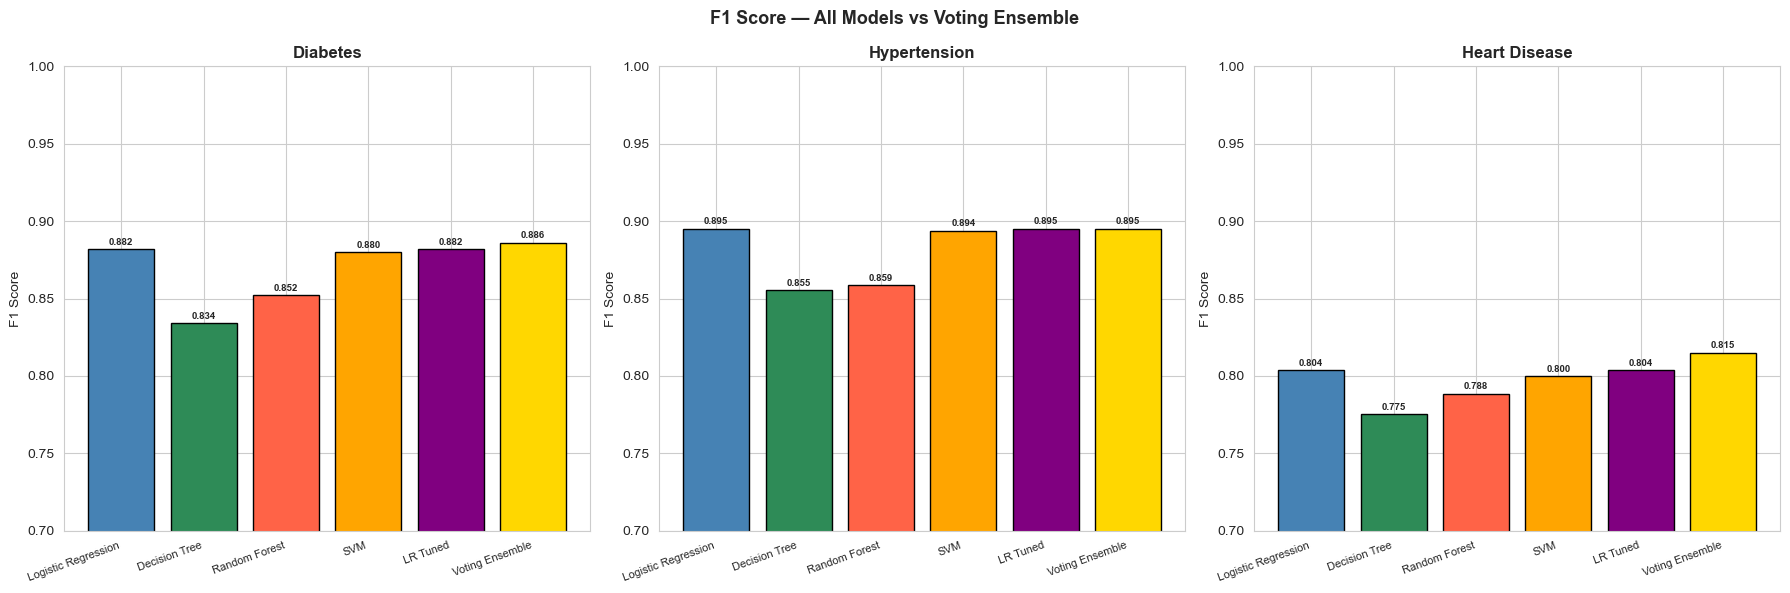

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

all_model_names = list(models.keys()) + ['LR Tuned', 'Voting Ensemble']
colors = ['steelblue', 'seagreen', 'tomato', 'orange', 'purple', 'gold']

for i, condition in enumerate(condition_names):
    f1_values = [results[condition][m]['f1'] for m in models.keys()]
    f1_values.append(best_models[condition]['f1'])
    f1_values.append(voting_results[condition]['f1'])

    bars = axes[i].bar(all_model_names, f1_values, 
                       color=colors, edgecolor='black')
    axes[i].set_title(condition, fontweight='bold')
    axes[i].set_ylim(0.7, 1.0)
    axes[i].set_xticklabels(all_model_names, rotation=20, ha='right', fontsize=8)
    axes[i].set_ylabel('F1 Score')

    for bar, val in zip(bars, f1_values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.003,
                     f'{val:.3f}', ha='center', fontsize=7, fontweight='bold')

plt.suptitle('F1 Score — All Models vs Voting Ensemble', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Save all three Voting Ensemble pipelines

In [110]:
import joblib
import os

# Create a models folder to store everything
os.makedirs('models', exist_ok=True)

# Save the three best pipelines (Voting Ensemble)
joblib.dump(voting_results['Diabetes']['pipeline'],     'models/diabetes_model.pkl')
joblib.dump(voting_results['Hypertension']['pipeline'], 'models/hypertension_model.pkl')
joblib.dump(voting_results['Heart Disease']['pipeline'],'models/heart_disease_model.pkl')

print("Models saved successfully!")
print("\nSaved files:")
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / (1024*1024)
    print(f"  {f}  ({size:.1f} MB)")

Models saved successfully!

Saved files:
  diabetes_model.pkl  (11.1 MB)
  heart_disease_model.pkl  (9.3 MB)
  hypertension_model.pkl  (11.2 MB)


# Save the feature list

In [113]:
import json

# Save feature list so deployment knows what inputs to expect
feature_info = {
    'features': FEATURES,
    'categorical_cols': categorical_cols,
    'numeric_cols': numeric_cols,
    'targets': {
        'diabetes': 'diabetes_target',
        'hypertension': 'hypertension_target',
        'heart_disease': 'heart_disease_target'
    },
    'threshold': 50
}

with open('models/feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=4)

print("Feature info saved!")
print(json.dumps(feature_info, indent=4))

Feature info saved!
{
    "features": [
        "Age",
        "gender",
        "ethnicity",
        "education_level",
        "income_level",
        "employment_status",
        "smoking_status",
        "alcohol_consumption_per_week",
        "physical_activity_minutes_per_week",
        "diet_score",
        "sleep_hours_per_day",
        "screen_time_hours_per_day",
        "family_history_diabetes",
        "hypertension_history",
        "cardiovascular_history",
        "bmi",
        "waist_to_hip_ratio",
        "systolic_bp",
        "diastolic_bp",
        "heart_rate",
        "cholesterol_total",
        "hdl_cholesterol",
        "ldl_cholesterol",
        "triglycerides",
        "glucose_fasting",
        "glucose_postprandial",
        "insulin_level",
        "hba1c"
    ],
    "categorical_cols": [
        "gender",
        "ethnicity",
        "education_level",
        "income_level",
        "employment_status",
        "smoking_status"
    ],
    "numeric_cols

# Load models back and test

In [116]:
# Load models fresh from disk (simulates deployment)
model_diabetes     = joblib.load('models/diabetes_model.pkl')
model_hypertension = joblib.load('models/hypertension_model.pkl')
model_heart        = joblib.load('models/heart_disease_model.pkl')

print("Models loaded successfully!")

Models loaded successfully!


# Create unseen test samples

In [119]:
# Create 3 unseen patient profiles to test

unseen_patients = pd.DataFrame({
    'Age':                                [45,    62,    28   ],
    'gender':                             ['Male','Female','Male'],
    'ethnicity':                          ['Asian','White','Hispanic'],
    'education_level':                    ['Graduate','Postgraduate','Highschool'],
    'income_level':                       ['Middle','High','Low'],
    'employment_status':                  ['Employed','Retired','Employed'],
    'smoking_status':                     ['Current','Never','Never'],
    'alcohol_consumption_per_week':       [10,    2,     0    ],
    'physical_activity_minutes_per_week': [60,    150,   300  ],
    'diet_score':                         [4.5,   7.2,   8.1  ],
    'sleep_hours_per_day':                [5.0,   7.5,   8.0  ],
    'screen_time_hours_per_day':          [8.0,   3.0,   2.0  ],
    'family_history_diabetes':            [1,     1,     0    ],
    'hypertension_history':               [1,     0,     0    ],
    'cardiovascular_history':             [0,     1,     0    ],
    'bmi':                                [29.5,  27.1,  22.3 ],
    'waist_to_hip_ratio':                 [0.92,  0.85,  0.78 ],
    'systolic_bp':                        [145,   118,   110  ],
    'diastolic_bp':                       [95,    75,    70   ],
    'heart_rate':                         [88,    72,    65   ],
    'cholesterol_total':                  [220,   185,   160  ],
    'hdl_cholesterol':                    [38,    55,    62   ],
    'ldl_cholesterol':                    [145,   110,   85   ],
    'triglycerides':                      [180,   120,   90   ],
    'glucose_fasting':                    [115,   95,    85   ],
    'glucose_postprandial':               [160,   120,   105  ],
    'insulin_level':                      [18.5,  10.2,  7.8  ],
    'hba1c':                              [6.2,   5.4,   5.1  ]
})

patient_labels = ['Patient A (High Risk)', 
                  'Patient B (Medium Risk)', 
                  'Patient C (Low Risk)']

print("Unseen patients created!")
print(unseen_patients[['Age', 'gender', 'bmi', 
                        'systolic_bp', 'glucose_fasting']].to_string())

Unseen patients created!
   Age  gender   bmi  systolic_bp  glucose_fasting
0   45    Male  29.5          145              115
1   62  Female  27.1          118               95
2   28    Male  22.3          110               85


# Run predictions

In [124]:
# Predict for all 3 patients across all 3 conditions
d_preds  = model_diabetes.predict(unseen_patients)
h_preds  = model_hypertension.predict(unseen_patients)
hd_preds = model_heart.predict(unseen_patients)

def label(pred):
    return ' AT RISK' if pred == 1 else ' NOT AT RISK'

print("=" * 55)
print("       HEALTH RISK PREDICTION RESULTS")
print("=" * 55)

for i, patient in enumerate(patient_labels):
    print(f"\n {patient}")
    print(f"    Diabetes      : {label(d_preds[i])}")
    print(f"    Heart Disease : {label(hd_preds[i])}")
    print(f"    Hypertension  : {label(h_preds[i])}")

print("\n" + "=" * 55)

       HEALTH RISK PREDICTION RESULTS

 Patient A (High Risk)
    Diabetes      :  AT RISK
    Heart Disease :  NOT AT RISK
    Hypertension  :  AT RISK

 Patient B (Medium Risk)
    Diabetes      :  NOT AT RISK
    Heart Disease :  NOT AT RISK
    Hypertension  :  NOT AT RISK

 Patient C (Low Risk)
    Diabetes      :  NOT AT RISK
    Heart Disease :  NOT AT RISK
    Hypertension  :  NOT AT RISK



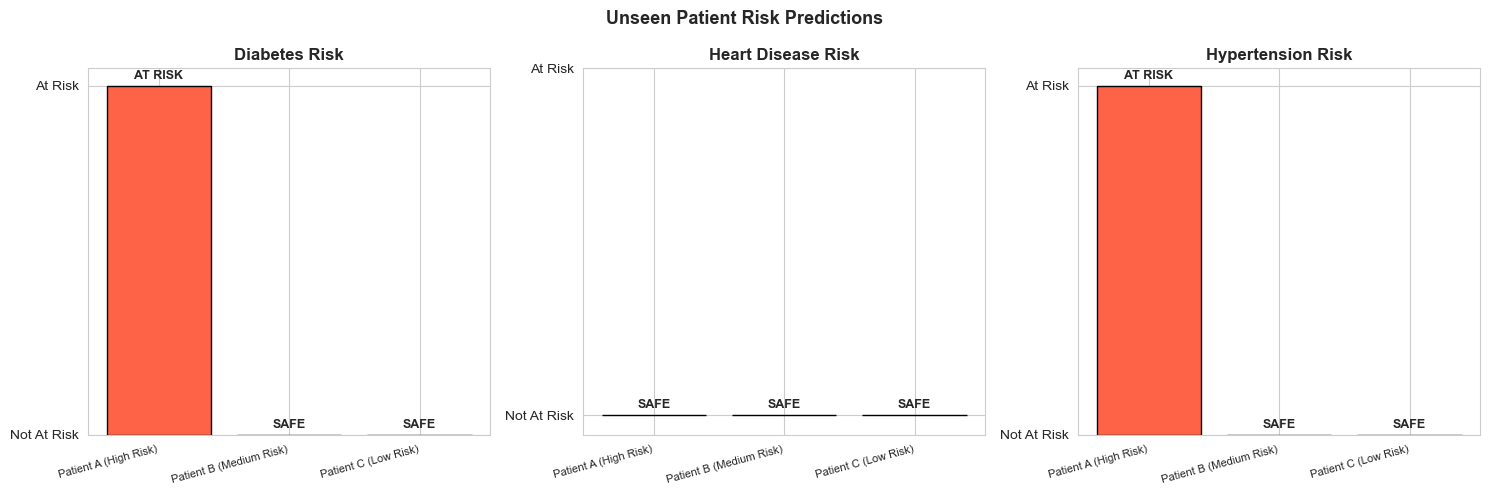

# Build Bagging Classifier

In [135]:
from sklearn.ensemble import BaggingClassifier

print("=== Bagging Classifier ===\n")

bagging_results = {}

for condition, (X_tr, X_te, y_tr, y_te) in conditions.items():
    print(f"Training Bagging for {condition}...")
    
    pipe_bagging = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', BaggingClassifier(
            estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=10),
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    pipe_bagging.fit(X_tr, y_tr)
    y_pred = pipe_bagging.predict(X_te)
    
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    
    bagging_results[condition] = {
        'pipeline': pipe_bagging,
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1
    }
    
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print()

print("Bagging training complete!")

=== Bagging Classifier ===

Training Bagging for Diabetes...
  Accuracy  : 0.9433
  Precision : 0.8227
  Recall    : 0.9308
  F1 Score  : 0.8734

Training Bagging for Hypertension...
  Accuracy  : 0.9390
  Precision : 0.8386
  Recall    : 0.9337
  F1 Score  : 0.8836

Training Bagging for Heart Disease...
  Accuracy  : 0.9446
  Precision : 0.7491
  Recall    : 0.9033
  F1 Score  : 0.8190

Bagging training complete!


# Stacking Classifier

In [138]:
from sklearn.ensemble import StackingClassifier

print("=== Stacking Classifier ===\n")

stacking_results = {}

for condition, (X_tr, X_te, y_tr, y_te) in conditions.items():
    print(f"Training Stacking for {condition}...")
    
    # Base models
    estimators = [
        ('lr',  LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
        ('dt',  DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)),
        ('rf',  RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
        ('svm', LinearSVC(class_weight='balanced', max_iter=2000, random_state=42))
    ]
    
    # Meta-model that learns from base model predictions
    stacking_clf = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
        cv=5,
        n_jobs=-1
    )
    
    pipe_stacking = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', stacking_clf)
    ])
    
    pipe_stacking.fit(X_tr, y_tr)
    y_pred = pipe_stacking.predict(X_te)
    
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    
    stacking_results[condition] = {
        'pipeline': pipe_stacking,
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1
    }
    
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print()

print("Stacking training complete!")

=== Stacking Classifier ===

Training Stacking for Diabetes...
  Accuracy  : 0.9456
  Precision : 0.8143
  Recall    : 0.9604
  F1 Score  : 0.8814

Training Stacking for Hypertension...
  Accuracy  : 0.9445
  Precision : 0.8416
  Recall    : 0.9559
  F1 Score  : 0.8951

Training Stacking for Heart Disease...
  Accuracy  : 0.9348
  Precision : 0.6937
  Recall    : 0.9489
  F1 Score  : 0.8015

Stacking training complete!


# Compare all three ensemble methods

In [141]:
print("=== Ensemble Methods Comparison ===\n")

for condition in conditions:
    print(f"--- {condition} ---")
    print(f"{'Method':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("-" * 60)
    
    for label, res in [
        ('Voting',   voting_results[condition]),
        ('Bagging',  bagging_results[condition]),
        ('Stacking', stacking_results[condition])
    ]:
        print(f"{label:<20} {res['accuracy']:>10.4f} {res['precision']:>10.4f} "
              f"{res['recall']:>10.4f} {res['f1']:>10.4f}")
    print()

=== Ensemble Methods Comparison ===

--- Diabetes ---
Method                 Accuracy  Precision     Recall         F1
------------------------------------------------------------
Voting                   0.9488     0.8323     0.9472     0.8860
Bagging                  0.9433     0.8227     0.9308     0.8734
Stacking                 0.9456     0.8143     0.9604     0.8814

--- Hypertension ---
Method                 Accuracy  Precision     Recall         F1
------------------------------------------------------------
Voting                   0.9453     0.8531     0.9414     0.8951
Bagging                  0.9390     0.8386     0.9337     0.8836
Stacking                 0.9445     0.8416     0.9559     0.8951

--- Heart Disease ---
Method                 Accuracy  Precision     Recall         F1
------------------------------------------------------------
Voting                   0.9408     0.7194     0.9400     0.8150
Bagging                  0.9446     0.7491     0.9033     0.8190
Sta

# Visualize ensemble comparison

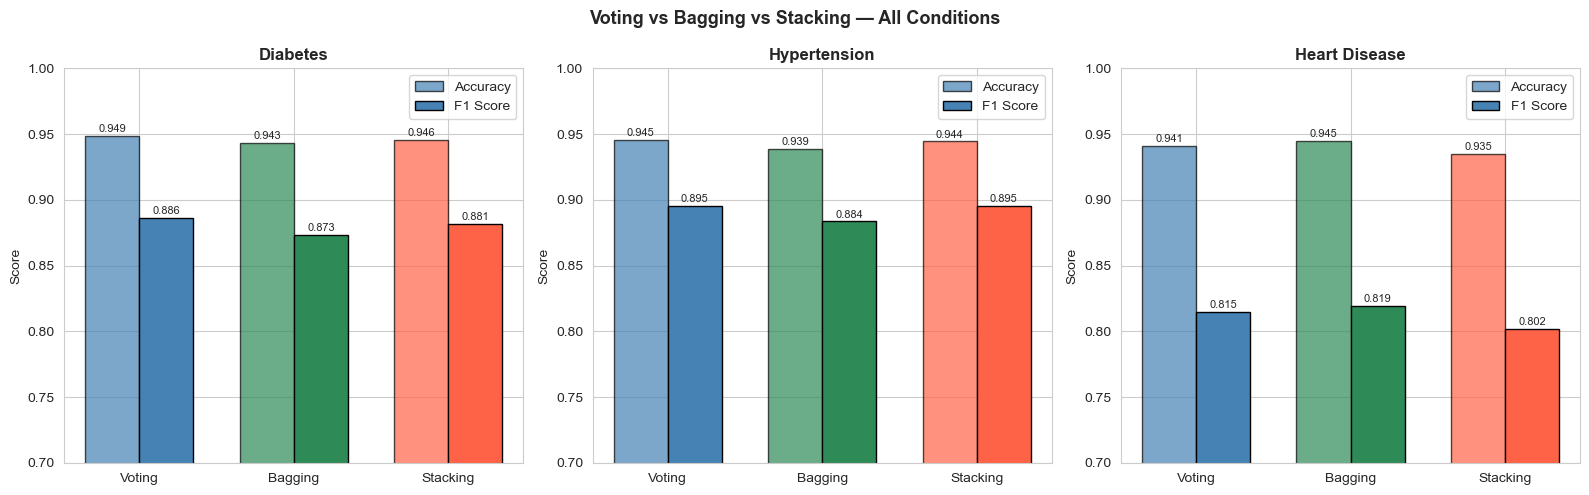

In [144]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ensemble_methods = ['Voting', 'Bagging', 'Stacking']
ensemble_results_list = [voting_results, bagging_results, stacking_results]
colors = ['steelblue', 'seagreen', 'tomato']

for i, condition in enumerate(condition_names):
    f1_values = [res[condition]['f1'] for res in ensemble_results_list]
    acc_values = [res[condition]['accuracy'] for res in ensemble_results_list]
    
    x = np.arange(len(ensemble_methods))
    width = 0.35
    
    bars1 = axes[i].bar(x - width/2, acc_values, width, 
                         label='Accuracy', color=colors, edgecolor='black', alpha=0.7)
    bars2 = axes[i].bar(x + width/2, f1_values, width,
                         label='F1 Score', color=colors, edgecolor='black')
    
    axes[i].set_title(condition, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(ensemble_methods)
    axes[i].set_ylim(0.7, 1.0)
    axes[i].legend()
    axes[i].set_ylabel('Score')
    
    for bar in bars1:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.003,
                     f'{bar.get_height():.3f}',
                     ha='center', fontsize=8)
    for bar in bars2:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.003,
                     f'{bar.get_height():.3f}',
                     ha='center', fontsize=8)

plt.suptitle('Voting vs Bagging vs Stacking — All Conditions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [146]:
import joblib, os

os.makedirs('models', exist_ok=True)

# Voting is best for Diabetes and Hypertension
# Bagging is best for Heart Disease
joblib.dump(voting_results['Diabetes']['pipeline'],      'models/diabetes_model.pkl')
joblib.dump(voting_results['Hypertension']['pipeline'],  'models/hypertension_model.pkl')
joblib.dump(bagging_results['Heart Disease']['pipeline'],'models/heart_disease_model.pkl')

print("Best models saved!")
print("  Diabetes      → Voting Ensemble")
print("  Hypertension  → Voting Ensemble")
print("  Heart Disease → Bagging Classifier")

for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / (1024*1024)
    print(f"  {f}  ({size:.1f} MB)")

Best models saved!
  Diabetes      → Voting Ensemble
  Hypertension  → Voting Ensemble
  Heart Disease → Bagging Classifier
  diabetes_model.pkl  (11.1 MB)
  feature_info.json  (0.0 MB)
  heart_disease_model.pkl  (7.6 MB)
  hypertension_model.pkl  (11.2 MB)


# Load updated models

In [150]:
model_diabetes     = joblib.load('models/diabetes_model.pkl')
model_hypertension = joblib.load('models/hypertension_model.pkl')
model_heart        = joblib.load('models/heart_disease_model.pkl')

print("Models loaded!")
print("  Diabetes      → Voting Ensemble")
print("  Hypertension  → Voting Ensemble")
print("  Heart Disease → Bagging Classifier")

Models loaded!
  Diabetes      → Voting Ensemble
  Hypertension  → Voting Ensemble
  Heart Disease → Bagging Classifier


# Final predictions

In [156]:
d_preds  = model_diabetes.predict(unseen_patients)
h_preds  = model_hypertension.predict(unseen_patients)
hd_preds = model_heart.predict(unseen_patients)

def label(pred):
    return ' AT RISK' if pred == 1 else ' NOT AT RISK'


print("HEALTH RISK PREDICTION RESULTS")


for i, patient in enumerate(patient_labels):
    print(f"\n {patient}")
    print(f"    Diabetes      : {label(d_preds[i])}")
    print(f"    Heart Disease : {label(hd_preds[i])}")
    print(f"    Hypertension  : {label(h_preds[i])}")
    print(f"   Model used:")
    print(f"      Diabetes/Hypertension → Voting Ensemble")
    print(f"      Heart Disease         → Bagging Classifier")



HEALTH RISK PREDICTION RESULTS

 Patient A (High Risk)
    Diabetes      :  AT RISK
    Heart Disease :  NOT AT RISK
    Hypertension  :  AT RISK
   Model used:
      Diabetes/Hypertension → Voting Ensemble
      Heart Disease         → Bagging Classifier

 Patient B (Medium Risk)
    Diabetes      :  NOT AT RISK
    Heart Disease :  NOT AT RISK
    Hypertension  :  NOT AT RISK
   Model used:
      Diabetes/Hypertension → Voting Ensemble
      Heart Disease         → Bagging Classifier

 Patient C (Low Risk)
    Diabetes      :  NOT AT RISK
    Heart Disease :  NOT AT RISK
    Hypertension  :  NOT AT RISK
   Model used:
      Diabetes/Hypertension → Voting Ensemble
      Heart Disease         → Bagging Classifier


# Visualize predictions

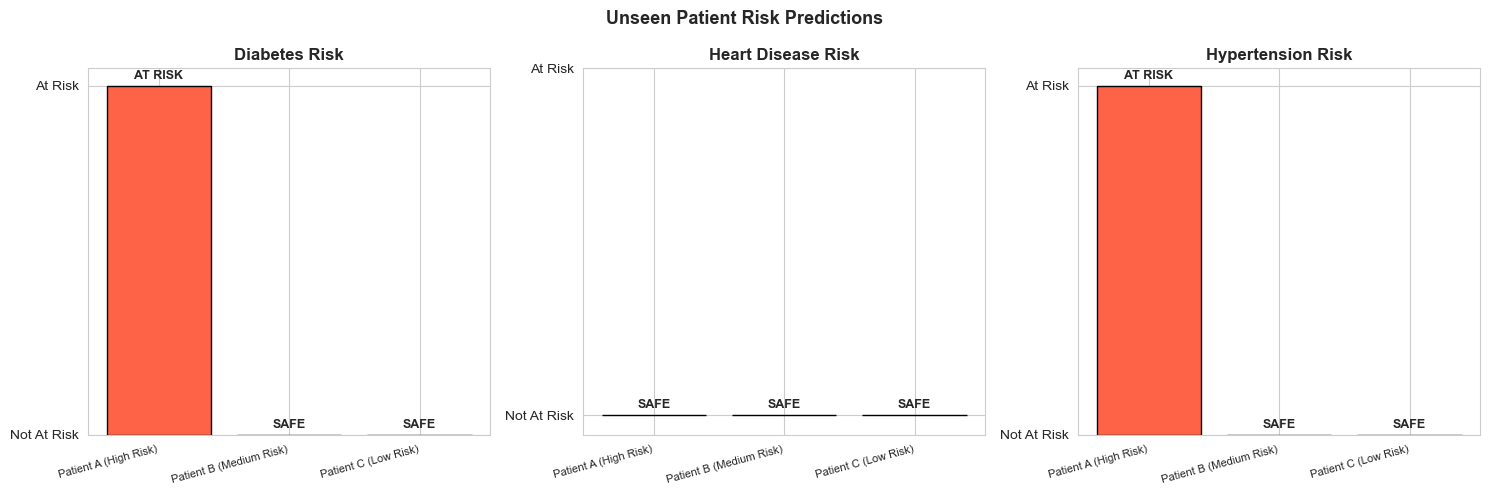

In [159]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

conditions_list = ['Diabetes', 'Heart Disease', 'Hypertension']
all_preds = [d_preds, hd_preds, h_preds]
colors_map = {0: 'seagreen', 1: 'tomato'}

for i, (condition, preds) in enumerate(zip(conditions_list, all_preds)):
    colors_bar = [colors_map[p] for p in preds]
    bars = axes[i].bar(patient_labels, preds, color=colors_bar, edgecolor='black')
    axes[i].set_title(f'{condition} Risk', fontweight='bold')
    axes[i].set_yticks([0, 1])
    axes[i].set_yticklabels(['Not At Risk', 'At Risk'])
    axes[i].set_xticklabels(patient_labels, rotation=15, ha='right', fontsize=8)
    
    for bar, pred in zip(bars, preds):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.02,
                     'AT RISK' if pred == 1 else 'SAFE',
                     ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Unseen Patient Risk Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()